<a href="https://colab.research.google.com/github/grownsandip/ML_Algo/blob/main/movie_genre_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is about predicting movie genre using decision tree

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


load the dataset from google drive to clab environment

In [2]:
import pandas as pd
path="/content/drive/MyDrive/dataset/movie_genre.csv"
data=pd.read_csv(path)

In [5]:
data.describe()

,release_year
count,11059.000000
mean,2014.209603
std,8.959517
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
#lets see the percemtage of missing values in dataset
percentage=(100* data.isnull().sum()/len(data))

In [8]:
print("percentage of missing values:",percentage)

percentage of missing values: type             0.000000
title            0.000000
cast            12.342888
country         24.369292
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64


**Dropping rows with missing values**
We don't have 24 percent of the data that relates to the country attribute and 12 percent of the data that relates to the cast attribute, so with this method, we lose at least 24 percent of our data; which seems not good.

**Replacing with mean/median/mode**
In this method we replace the missing values with mean, median, or mode. Because here the columns that have missing values are categorical, we replace missing values with mode.

In [9]:
data['country'].fillna(data['country'].mode()[0], inplace=True)
data['cast'].fillna(data['cast'].mode()[0], inplace=True)

<ipython-input-9-ed9e306bde2b>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['country'].fillna(data['country'].mode()[0], inplace=True)
<ipython-input-9-ed9e306bde2b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [10]:
print(data.isnull().sum())

type            0
title           0
cast            0
country         0
release_year    0
listed_in       0
description     0
dtype: int64


**So we got rid of missing values**

In [11]:
data.head()

,type,title,cast,country,release_year,listed_in,description
0,Movie,Dick Johnson Is Dead,David Attenborough,United States,2020,Documentaries,"As her father nears the end of his life, filmm..."
1,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,TV Show,Jailbirds New Orleans,David Attenborough,United States,2021,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,TV Show,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


There are too many categorical data in dataset and we need to label encode them

In [13]:
from sklearn import preprocessing
def categorical_to_numerical(data, columns, method='Label_Encoding'):
    if method == 'Label_Encoding':
        le = preprocessing.LabelEncoder()
        for col in columns:
            le.fit(data[col])
            data[col] = le.transform(data[col])

categorical_to_numerical(data, ['country', 'type'])

In [14]:
data.head()

,type,title,cast,country,release_year,listed_in,description
0,0,Dick Johnson Is Dead,David Attenborough,608,2020,Documentaries,"As her father nears the end of his life, filmm..."
1,1,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",430,2021,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,1,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",608,2021,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,1,Jailbirds New Orleans,David Attenborough,608,2021,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,1,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",254,2021,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11059 entries, 0 to 11058
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          11059 non-null  int64 
 1   title         11059 non-null  object
 2   cast          11059 non-null  object
 3   country       11059 non-null  int64 
 4   release_year  11059 non-null  int64 
 5   listed_in     11059 non-null  object
 6   description   11059 non-null  object
dtypes: int64(3), object(4)
memory usage: 604.9+ KB


we create another dataframe where we shall convert rest cast,title,listed_in,descrition

In [16]:
import copy
df=copy.deepcopy(data)
categorical_to_numerical(df, ['cast', 'title', 'listed_in', 'description'])

In [17]:
df.head()

,type,title,cast,country,release_year,listed_in,description
0,0,2454,2073,608,2020,500,2886
1,1,1345,486,430,2021,749,1969
2,1,3366,7616,608,2021,468,9326
3,1,4403,2073,608,2021,566,4263
4,1,4827,5839,254,2021,728,5328


**Handling set attributes**

First we identify which genres we have in this dataset and we add new columns based on those generes. Then we go through each movie and check the genres which that movie contains.

In [18]:
def separating_set_attributes(data, columns):
    for col in columns:
        attributes_set = set()
        for features in data[col]:
            for feature in features.split(', '):
                attributes_set.add(feature)

        for feature in attributes_set:
            data[feature] = 0

        for index, row in data.iterrows():
            for feature in row[col].split(', '):
                data.at[index, feature] = 1

In [20]:
separating_set_attributes(data,["listed_in"])

In [22]:
data.head()

,type,title,cast,country,release_year,listed_in,description,Kids' TV,Coming of Age,Spy/Espionage,...,Independent Movies,Action & Adventure,Unscripted,Adventure,Special Interest,Animals & Nature,International Movies,Romantic TV Shows,Horror,Reality
0,0,Dick Johnson Is Dead,David Attenborough,608,2020,Documentaries,"As her father nears the end of his life, filmm...",0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",430,2021,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",608,2021,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,Jailbirds New Orleans,David Attenborough,608,2021,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",254,2021,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [23]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Extracting features from text
Because we have text features, we can split the text into its words and count the number of most frequented words in the whole dataset. Then we can iterate over the rows of our dataset and determine which of those most frequented words appear in this row.

Count Vectorizer
Count Vectorizer is used to transform a given text into a vector on the basis of the frequency (count) of each word that occurs in the entire text.

In [24]:
def get_top_n_words(feature, n, stop_words=None, token_pattern=r'(?u)\b\w\w+\b'):
    vectorizer = CountVectorizer(stop_words=stop_words, token_pattern=token_pattern)
    X = vectorizer.fit_transform(feature)
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

In [25]:
cast_features = get_top_n_words(data['cast'], 10, token_pattern='(?u)\w+[\s\`]\w+')
data['description+title'] = data['title'] + ' ' + data['description']
desc_and_title_features = get_top_n_words(data['description+title'], 50, stop_words=stopwords.words('english'))

<ipython-input-25-4318709943a3>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['description+title'] = data['title'] + ' ' + data['description']


In [26]:
data.head()

,type,title,cast,country,release_year,listed_in,description,Kids' TV,Coming of Age,Spy/Espionage,...,Action & Adventure,Unscripted,Adventure,Special Interest,Animals & Nature,International Movies,Romantic TV Shows,Horror,Reality,description+title
0,0,Dick Johnson Is Dead,David Attenborough,608,2020,Documentaries,"As her father nears the end of his life, filmm...",0,0,0,...,0,0,0,0,0,0,0,0,0,Dick Johnson Is Dead As her father nears the e...
1,1,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",430,2021,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,0,0,...,0,0,0,0,0,0,0,0,0,"Blood & Water After crossing paths at a party,..."
2,1,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",608,2021,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,0,0,...,0,0,0,0,0,0,0,0,0,Ganglands To protect his family from a powerfu...
3,1,Jailbirds New Orleans,David Attenborough,608,2021,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,0,0,...,0,0,0,0,0,0,0,0,0,"Jailbirds New Orleans Feuds, flirtations and t..."
4,1,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",254,2021,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,0,0,...,0,0,0,0,0,0,1,0,0,Kota Factory In a city of coaching centers kno...


In [27]:
def set_text_features(data, features, columns):
    text_features = []
    for feature in features:
        text_features.append(feature[0])
        data[feature[0]] = 0
    for col in columns:
        if col == 'cast':
            vectorizer = CountVectorizer(token_pattern='(?u)\w+[\s\`]\w+')
        else:
            vectorizer = CountVectorizer()
        analyze = vectorizer.build_analyzer()
        for index, row in data.iterrows():
            count = dict(Counter(analyze(row[col])))
            for k, v in count.items():
                if k in text_features:
                    data.at[index, k] = v

In [28]:
set_text_features(data, desc_and_title_features+cast_features, ['description+title', 'cast'])

<ipython-input-27-90c4f36129e0>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[feature[0]] = 0
<ipython-input-27-90c4f36129e0>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[feature[0]] = 0
<ipython-input-27-90c4f36129e0>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[feature[0]]

In [29]:
data.head()

,type,title,cast,country,release_year,listed_in,description,Kids' TV,Coming of Age,Spy/Espionage,...,david attenborough,anupam kher,juan pablo,shah rukh,takahiro sakurai,julie tejwani,naseeruddin shah,rupa bhimani,yuki kaji,akshay kumar
0,0,Dick Johnson Is Dead,David Attenborough,608,2020,Documentaries,"As her father nears the end of his life, filmm...",0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,1,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",430,2021,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",608,2021,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,Jailbirds New Orleans,David Attenborough,608,2021,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,1,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",254,2021,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
X = copy.deepcopy(data.drop(columns=['type', 'title', 'description', 'cast', 'listed_in', 'description+title']))
Y = data['type']

In [31]:
print(X)
print(Y)

       country  release_year  Kids' TV  Coming of Age  Spy/Espionage  Travel  \
0          608          2020         0              0              0       0   
1          430          2021         0              0              0       0   
2          608          2021         0              0              0       0   
3          608          2021         0              0              0       0   
4          254          2021         0              0              0       0   
...        ...           ...       ...            ...            ...     ...   
11054      608          2000         0              0              0       0   
11055      608          1996         0              1              0       0   
11056      608          2014         0              1              0       0   
11057       59          2016         0              0              0       0   
11058      608          2008         0              0              0       0   

       Lifestyle  Fitness  Survival  Ar

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

In [33]:
X_train.shape

(8847, 157)

In [34]:
X_test.shape

(2212, 157)

In [35]:
Y_train.shape

(8847,)

In [36]:
Y_test.shape

(2212,)

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics, tree
clf = tree.DecisionTreeClassifier(max_depth=11, min_samples_split=2)
clf = clf.fit(X_train,Y_train)

In [40]:
y_pred = clf.predict(X_test)

In [41]:
print("Accuracy:", metrics.accuracy_score(Y_test, y_pred))

Accuracy: 0.9990958408679927


In [47]:
from sklearn.metrics import confusion_matrix
conf=confusion_matrix(Y_test, y_pred)
print(conf)

[[1204    2]
 [   0 1006]]


[Text(0.8571428571428571, 0.9583333333333334, 'x[93] <= 0.5\ngini = 0.494\nsamples = 8847\nvalue = [4925.0, 3922.0]'),
 Text(0.7857142857142857, 0.875, 'x[65] <= 0.5\ngini = 0.483\nsamples = 6622\nvalue = [2700, 3922]'),
 Text(0.8214285714285714, 0.9166666666666667, 'True  '),
 Text(0.7142857142857143, 0.7916666666666666, 'x[10] <= 0.5\ngini = 0.443\nsamples = 5870\nvalue = [1948.0, 3922.0]'),
 Text(0.6428571428571429, 0.7083333333333334, 'x[54] <= 0.5\ngini = 0.391\nsamples = 5349\nvalue = [1427, 3922]'),
 Text(0.5714285714285714, 0.625, 'x[63] <= 0.5\ngini = 0.316\nsamples = 4881\nvalue = [959, 3922]'),
 Text(0.5, 0.5416666666666666, 'x[62] <= 0.5\ngini = 0.253\nsamples = 4605\nvalue = [683, 3922]'),
 Text(0.42857142857142855, 0.4583333333333333, 'x[88] <= 0.5\ngini = 0.19\nsamples = 4388\nvalue = [466, 3922]'),
 Text(0.35714285714285715, 0.375, 'x[21] <= 0.5\ngini = 0.123\nsamples = 4199\nvalue = [277, 3922]'),
 Text(0.2857142857142857, 0.2916666666666667, 'x[41] <= 0.5\ngini = 0.06

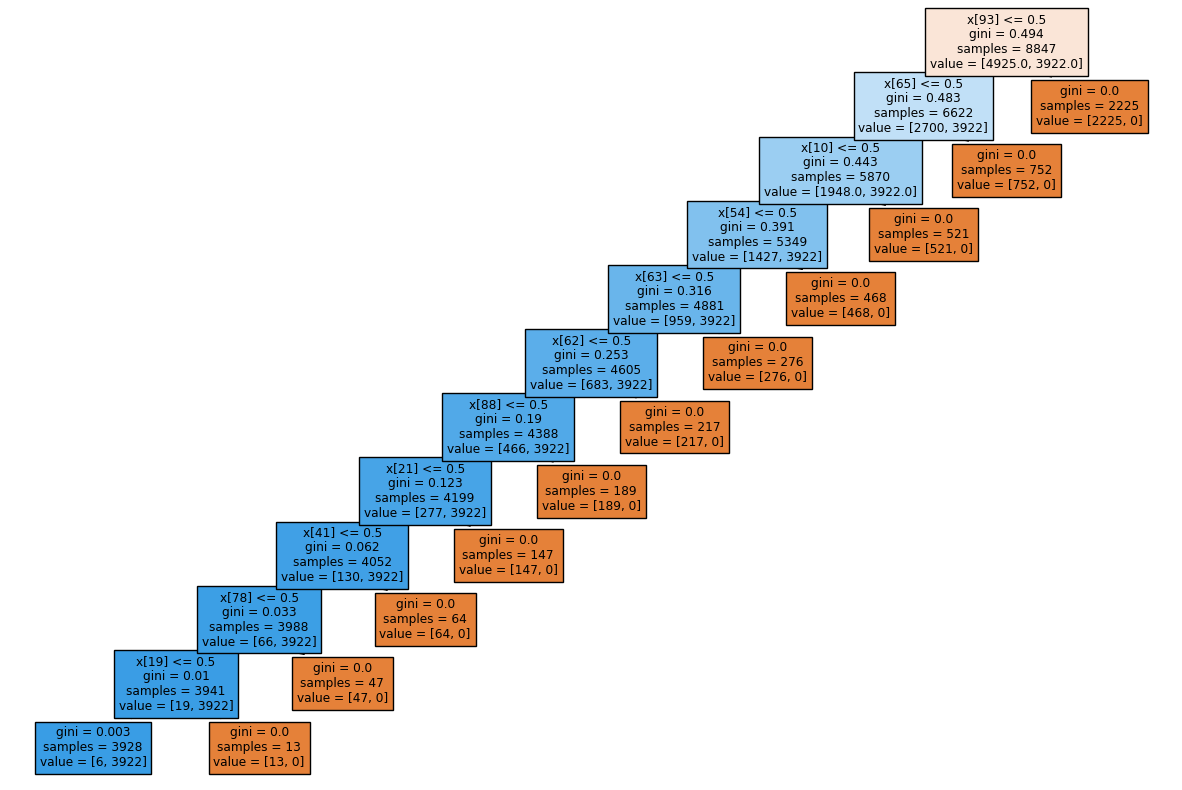

In [48]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
tree.plot_tree(clf,filled=True)